In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.1.3
Pandas: 2.2.3
TensorFlow: 2.21.0


In [ ]:
FILE_PATH = "AirQualityUCI.xlsx"

df = pd.read_excel(FILE_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (9357, 15)

Columns:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

First 5 rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
df = df.copy()

df["timestamp"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    errors="coerce"
)

model_df = df[
    ["timestamp", "PT08.S1(CO)", "T", "RH"]
].copy()

model_df = model_df.rename(columns={
    "PT08.S1(CO)": "gas_sensor",
    "T": "temperature",
    "RH": "humidity"
})

model_df = model_df.replace(-200, np.nan)

model_df = model_df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", model_df.shape)

print("\nTime range:")
print(model_df["timestamp"].min(), "→", model_df["timestamp"].max())

print("\nMissing values:")
print(model_df.isna().sum())

print("\nFirst 5 cleaned rows:")
display(model_df.head())

Shape: (9357, 4)

Time range:
2004-03-10 18:00:00 → 2005-04-04 14:00:00

Missing values:
timestamp        0
gas_sensor     366
temperature    366
humidity       366
dtype: int64

First 5 cleaned rows:


,timestamp,gas_sensor,temperature,humidity
0,2004-03-10 18:00:00,1360.00,13.60,48.875001
1,2004-03-10 19:00:00,1292.25,13.30,47.700000
2,2004-03-10 20:00:00,1402.00,11.90,53.975000
3,2004-03-10 21:00:00,1375.50,11.00,60.000000
4,2004-03-10 22:00:00,1272.25,11.15,59.575001


In [ ]:
sensor_cols = ["gas_sensor", "temperature", "humidity"]

model_df[sensor_cols] = (
    model_df[sensor_cols]
    .interpolate(method="linear", limit=3, limit_direction="both")
)

print("Missing values after short-gap interpolation:")
print(model_df.isna().sum())

print("\nRows remaining with any missing sensor value:",
      model_df[sensor_cols].isna().any(axis=1).sum())

Missing values after short-gap interpolation:
timestamp        0
gas_sensor     291
temperature    291
humidity       291
dtype: int64

Rows remaining with any missing sensor value: 291


In [ ]:
valid_mask = model_df[sensor_cols].notna().all(axis=1)

segment_id = valid_mask.ne(valid_mask.shift()).cumsum()

segments = []

for seg_id, group in model_df.groupby(segment_id):
    if valid_mask.loc[group.index[0]]:
        segments.append({
            "segment_id": seg_id,
            "start": group["timestamp"].iloc[0],
            "end": group["timestamp"].iloc[-1],
            "length": len(group)
        })

segments_df = pd.DataFrame(segments)

print("Number of valid continuous segments:", len(segments_df))

print("\nLongest valid segments:")
display(
    segments_df
    .sort_values("length", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("\nTotal valid rows:",
      valid_mask.sum())

print("Rows still missing:",
      (~valid_mask).sum())

Number of valid continuous segments: 11

Longest valid segments:


,segment_id,start,end,length
0,13,2004-09-08 15:00:00,2004-12-14 19:00:00,2333
1,7,2004-06-21 01:00:00,2004-08-26 08:00:00,1592
2,21,2005-02-11 18:00:00,2005-04-04 14:00:00,1245
3,3,2004-04-09 20:00:00,2004-05-25 21:00:00,1106
4,1,2004-03-10 18:00:00,2004-04-09 01:00:00,704
5,5,2004-05-26 06:00:00,2004-06-19 16:00:00,587
6,17,2005-01-04 22:00:00,2005-01-28 19:00:00,574
7,15,2004-12-17 17:00:00,2005-01-02 23:00:00,391
8,9,2004-08-28 00:00:00,2004-09-08 01:00:00,266
9,19,2005-01-28 23:00:00,2005-02-08 19:00:00,261



Total valid rows: 9066
Rows still missing: 291


In [ ]:
valid_df = model_df.loc[valid_mask].copy().reset_index(drop=True)

n = len(valid_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = valid_df.iloc[:train_end].copy()
val_df = valid_df.iloc[train_end:val_end].copy()
test_df = valid_df.iloc[val_end:].copy()

print("Total valid rows:", n)

print("\nTrain:")
print("Shape:", train_df.shape)
print("Time:", train_df["timestamp"].iloc[0], "→", train_df["timestamp"].iloc[-1])

print("\nValidation:")
print("Shape:", val_df.shape)
print("Time:", val_df["timestamp"].iloc[0], "→", val_df["timestamp"].iloc[-1])

print("\nTest:")
print("Shape:", test_df.shape)
print("Time:", test_df["timestamp"].iloc[0], "→", test_df["timestamp"].iloc[-1])

Total valid rows: 9066

Train:
Shape: (6346, 4)
Time: 2004-03-10 18:00:00 → 2004-12-04 10:00:00

Validation:
Shape: (1360, 4)
Time: 2004-12-04 11:00:00 → 2005-02-04 00:00:00

Test:
Shape: (1360, 4)
Time: 2005-02-04 01:00:00 → 2005-04-04 14:00:00


In [ ]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train_df[sensor_cols]
)

val_scaled = scaler.transform(
    val_df[sensor_cols]
)

test_scaled = scaler.transform(
    test_df[sensor_cols]
)

print("Train scaled shape:", train_scaled.shape)
print("Validation scaled shape:", val_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

print("\nScaler means:")
print(dict(zip(sensor_cols, scaler.mean_)))

print("\nScaler standard deviations:")
print(dict(zip(sensor_cols, scaler.scale_)))

print("\nNaN check:")
print(
    "Train:", np.isnan(train_scaled).sum(),
    "| Val:", np.isnan(val_scaled).sum(),
    "| Test:", np.isnan(test_scaled).sum()
)

Train scaled shape: (6346, 3)
Validation scaled shape: (1360, 3)
Test scaled shape: (1360, 3)

Scaler means:
{'gas_sensor': np.float64(1099.6808094337641), 'temperature': np.float64(21.80153902412738), 'humidity': np.float64(47.540470376725025)}

Scaler standard deviations:
{'gas_sensor': np.float64(220.3688664059212), 'temperature': np.float64(7.665613549392686), 'humidity': np.float64(17.343671634766473)}

NaN check:
Train: 0 | Val: 0 | Test: 0


In [ ]:
LOOKBACK = 6
HORIZON = 3

def create_sequences(data, lookback, horizon):
    X = []
    y = []

    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback:i + lookback + horizon])

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


X_train, y_train = create_sequences(
    train_scaled,
    LOOKBACK,
    HORIZON
)

X_val, y_val = create_sequences(
    val_scaled,
    LOOKBACK,
    HORIZON
)

X_test, y_test = create_sequences(
    test_scaled,
    LOOKBACK,
    HORIZON
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)

print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

print("\nData type:", X_train.dtype)

print("\nNaN / Inf check:")
print("X_train NaN:", np.isnan(X_train).sum())
print("y_train NaN:", np.isnan(y_train).sum())
print("X_train Inf:", np.isinf(X_train).sum())
print("y_train Inf:", np.isinf(y_train).sum())

X_train: (6338, 6, 3)
y_train: (6338, 3, 3)
X_val:   (1352, 6, 3)
y_val:   (1352, 3, 3)
X_test:  (1352, 6, 3)
y_test:  (1352, 3, 3)

Data type: float32

NaN / Inf check:
X_train NaN: 0
y_train NaN: 0
X_train Inf: 0
y_train Inf: 0


In [ ]:
n_features = 3
n_targets = 3

model = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),

    layers.LSTM(
        32,
        activation="tanh",
        return_sequences=False
    ),

    layers.Dropout(0.2),

    layers.Dense(
        HORIZON * n_targets
    ),

    layers.Reshape(
        (HORIZON, n_targets)
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mae",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │           297 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,905 (19.16 KB)

 Trainable params: 4,905 (19.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed.")
print("Epochs actually trained:", len(history.history["loss"]))
print("Best validation MAE:",
      min(history.history["val_loss"]))

Epoch 1/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.5626 - mae: 0.5626 - val_loss: 0.4002 - val_mae: 0.4002
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4039 - mae: 0.4039 - val_loss: 0.3510 - val_mae: 0.3510
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3627 - mae: 0.3627 - val_loss: 0.3262 - val_mae: 0.3262
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3464 - mae: 0.3464 - val_loss: 0.3148 - val_mae: 0.3148
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3366 - mae: 0.3366 - val_loss: 0.3019 - val_mae: 0.3019
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3283 - mae: 0.3283 - val_loss: 0.2935 - val_mae: 0.2935
Epoch 7/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3213 - mae: 0.3213 - val_loss: 0.2875 - val_mae: 0.2875
Epoch 8/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3192 - mae: 0.3192 - val_loss: 0.2783 - val_mae: 0.2783
Epoch 9/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms

In [ ]:
y_pred = model.predict(X_test, verbose=0)


y_persistence = np.repeat(
    X_test[:, -1:, :],
    HORIZON,
    axis=1
)

print("LSTM prediction shape:", y_pred.shape)
print("Persistence shape:", y_persistence.shape)


lstm_mae = mean_absolute_error(
    y_test.reshape(-1),
    y_pred.reshape(-1)
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test.reshape(-1),
        y_pred.reshape(-1)
    )
)

baseline_mae = mean_absolute_error(
    y_test.reshape(-1),
    y_persistence.reshape(-1)
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test.reshape(-1),
        y_persistence.reshape(-1)
    )
)

print("\nOverall test performance")
print("-" * 40)
print(f"LSTM        MAE : {lstm_mae:.4f}")
print(f"LSTM        RMSE: {lstm_rmse:.4f}")
print(f"Persistence MAE : {baseline_mae:.4f}")
print(f"Persistence RMSE: {baseline_rmse:.4f}")

mae_improvement = (
    (baseline_mae - lstm_mae) / baseline_mae * 100
)

rmse_improvement = (
    (baseline_rmse - lstm_rmse) / baseline_rmse * 100
)

print(f"\nMAE improvement : {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

LSTM prediction shape: (1352, 3, 3)
Persistence shape: (1352, 3, 3)

Overall test performance
----------------------------------------
LSTM        MAE : 0.2742
LSTM        RMSE: 0.4052
Persistence MAE : 0.3465
Persistence RMSE: 0.5161

MAE improvement : 20.86%
RMSE improvement: 21.48%


In [ ]:
target_names = ["gas_sensor", "temperature", "humidity"]

print("Per-variable test performance")
print("=" * 60)

for i, name in enumerate(target_names):

    lstm_mae_i = mean_absolute_error(
        y_test[:, :, i].reshape(-1),
        y_pred[:, :, i].reshape(-1)
    )

    baseline_mae_i = mean_absolute_error(
        y_test[:, :, i].reshape(-1),
        y_persistence[:, :, i].reshape(-1)
    )

    improvement_i = (
        (baseline_mae_i - lstm_mae_i)
        / baseline_mae_i
        * 100
    )

    print(
        f"{name:12s} | "
        f"LSTM MAE: {lstm_mae_i:.4f} | "
        f"Baseline: {baseline_mae_i:.4f} | "
        f"Improvement: {improvement_i:.2f}%"
    )


print("\nPer-horizon test performance")
print("=" * 60)

for h in range(HORIZON):

    lstm_mae_h = mean_absolute_error(
        y_test[:, h, :].reshape(-1),
        y_pred[:, h, :].reshape(-1)
    )

    baseline_mae_h = mean_absolute_error(
        y_test[:, h, :].reshape(-1),
        y_persistence[:, h, :].reshape(-1)
    )

    improvement_h = (
        (baseline_mae_h - lstm_mae_h)
        / baseline_mae_h
        * 100
    )

    print(
        f"+{h+1} hour | "
        f"LSTM MAE: {lstm_mae_h:.4f} | "
        f"Baseline: {baseline_mae_h:.4f} | "
        f"Improvement: {improvement_h:.2f}%"
    )

Per-variable test performance
gas_sensor   | LSTM MAE: 0.3886 | Baseline: 0.4716 | Improvement: 17.61%
temperature  | LSTM MAE: 0.1671 | Baseline: 0.2178 | Improvement: 23.31%
humidity     | LSTM MAE: 0.2670 | Baseline: 0.3500 | Improvement: 23.71%

Per-horizon test performance
+1 hour | LSTM MAE: 0.1808 | Baseline: 0.2075 | Improvement: 12.88%
+2 hour | LSTM MAE: 0.2843 | Baseline: 0.3558 | Improvement: 20.12%
+3 hour | LSTM MAE: 0.3576 | Baseline: 0.4761 | Improvement: 24.89%


In [ ]:
y_test_real = scaler.inverse_transform(
    y_test.reshape(-1, n_features)
).reshape(y_test.shape)

y_pred_real = scaler.inverse_transform(
    y_pred.reshape(-1, n_features)
).reshape(y_pred.shape)

y_persistence_real = scaler.inverse_transform(
    y_persistence.reshape(-1, n_features)
).reshape(y_persistence.shape)

print("Real-unit prediction shape:", y_pred_real.shape)

print("\nReal-unit test performance")
print("=" * 60)

for i, name in enumerate(target_names):

    lstm_mae_real = mean_absolute_error(
        y_test_real[:, :, i].reshape(-1),
        y_pred_real[:, :, i].reshape(-1)
    )

    baseline_mae_real = mean_absolute_error(
        y_test_real[:, :, i].reshape(-1),
        y_persistence_real[:, :, i].reshape(-1)
    )

    improvement_real = (
        (baseline_mae_real - lstm_mae_real)
        / baseline_mae_real
        * 100
    )

    print(
        f"{name:12s} | "
        f"LSTM MAE: {lstm_mae_real:.3f} | "
        f"Baseline: {baseline_mae_real:.3f} | "
        f"Improvement: {improvement_real:.2f}%"
    )

Real-unit prediction shape: (1352, 3, 3)

Real-unit test performance
gas_sensor   | LSTM MAE: 85.630 | Baseline: 103.935 | Improvement: 17.61%
temperature  | LSTM MAE: 1.281 | Baseline: 1.670 | Improvement: 23.31%
humidity     | LSTM MAE: 4.630 | Baseline: 6.069 | Improvement: 23.71%


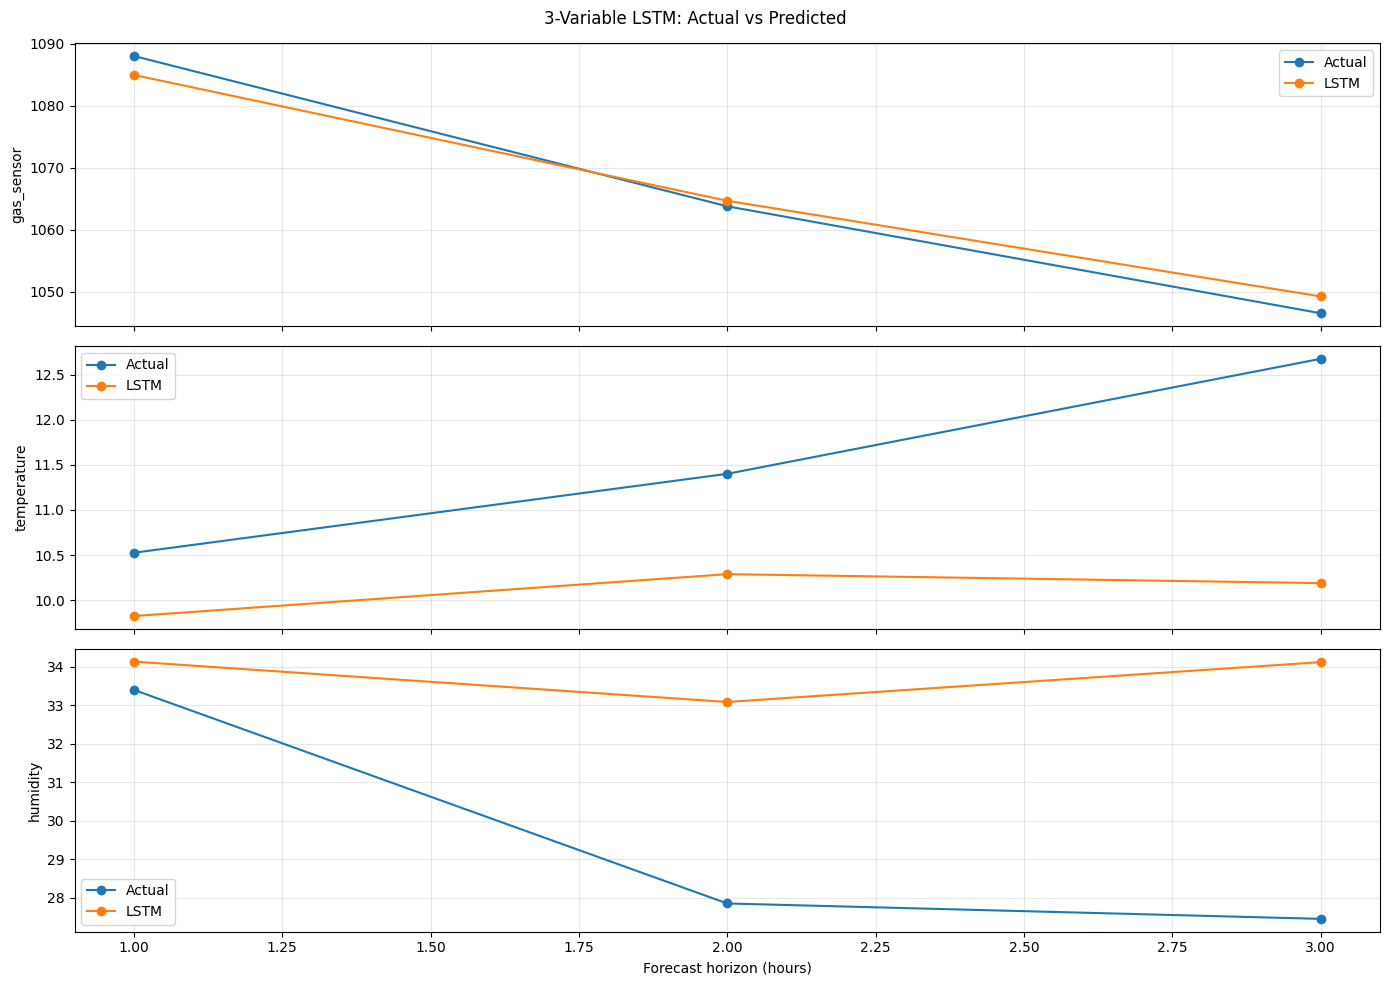

In [ ]:
sample_idx = 100

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 10),
    sharex=True
)

for i, name in enumerate(target_names):

    axes[i].plot(
        range(1, HORIZON + 1),
        y_test_real[sample_idx, :, i],
        marker="o",
        label="Actual"
    )

    axes[i].plot(
        range(1, HORIZON + 1),
        y_pred_real[sample_idx, :, i],
        marker="o",
        label="LSTM"
    )

    axes[i].set_ylabel(name)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

axes[-1].set_xlabel("Forecast horizon (hours)")

plt.suptitle(
    "3-Variable LSTM: Actual vs Predicted"
)

plt.tight_layout()
plt.show()

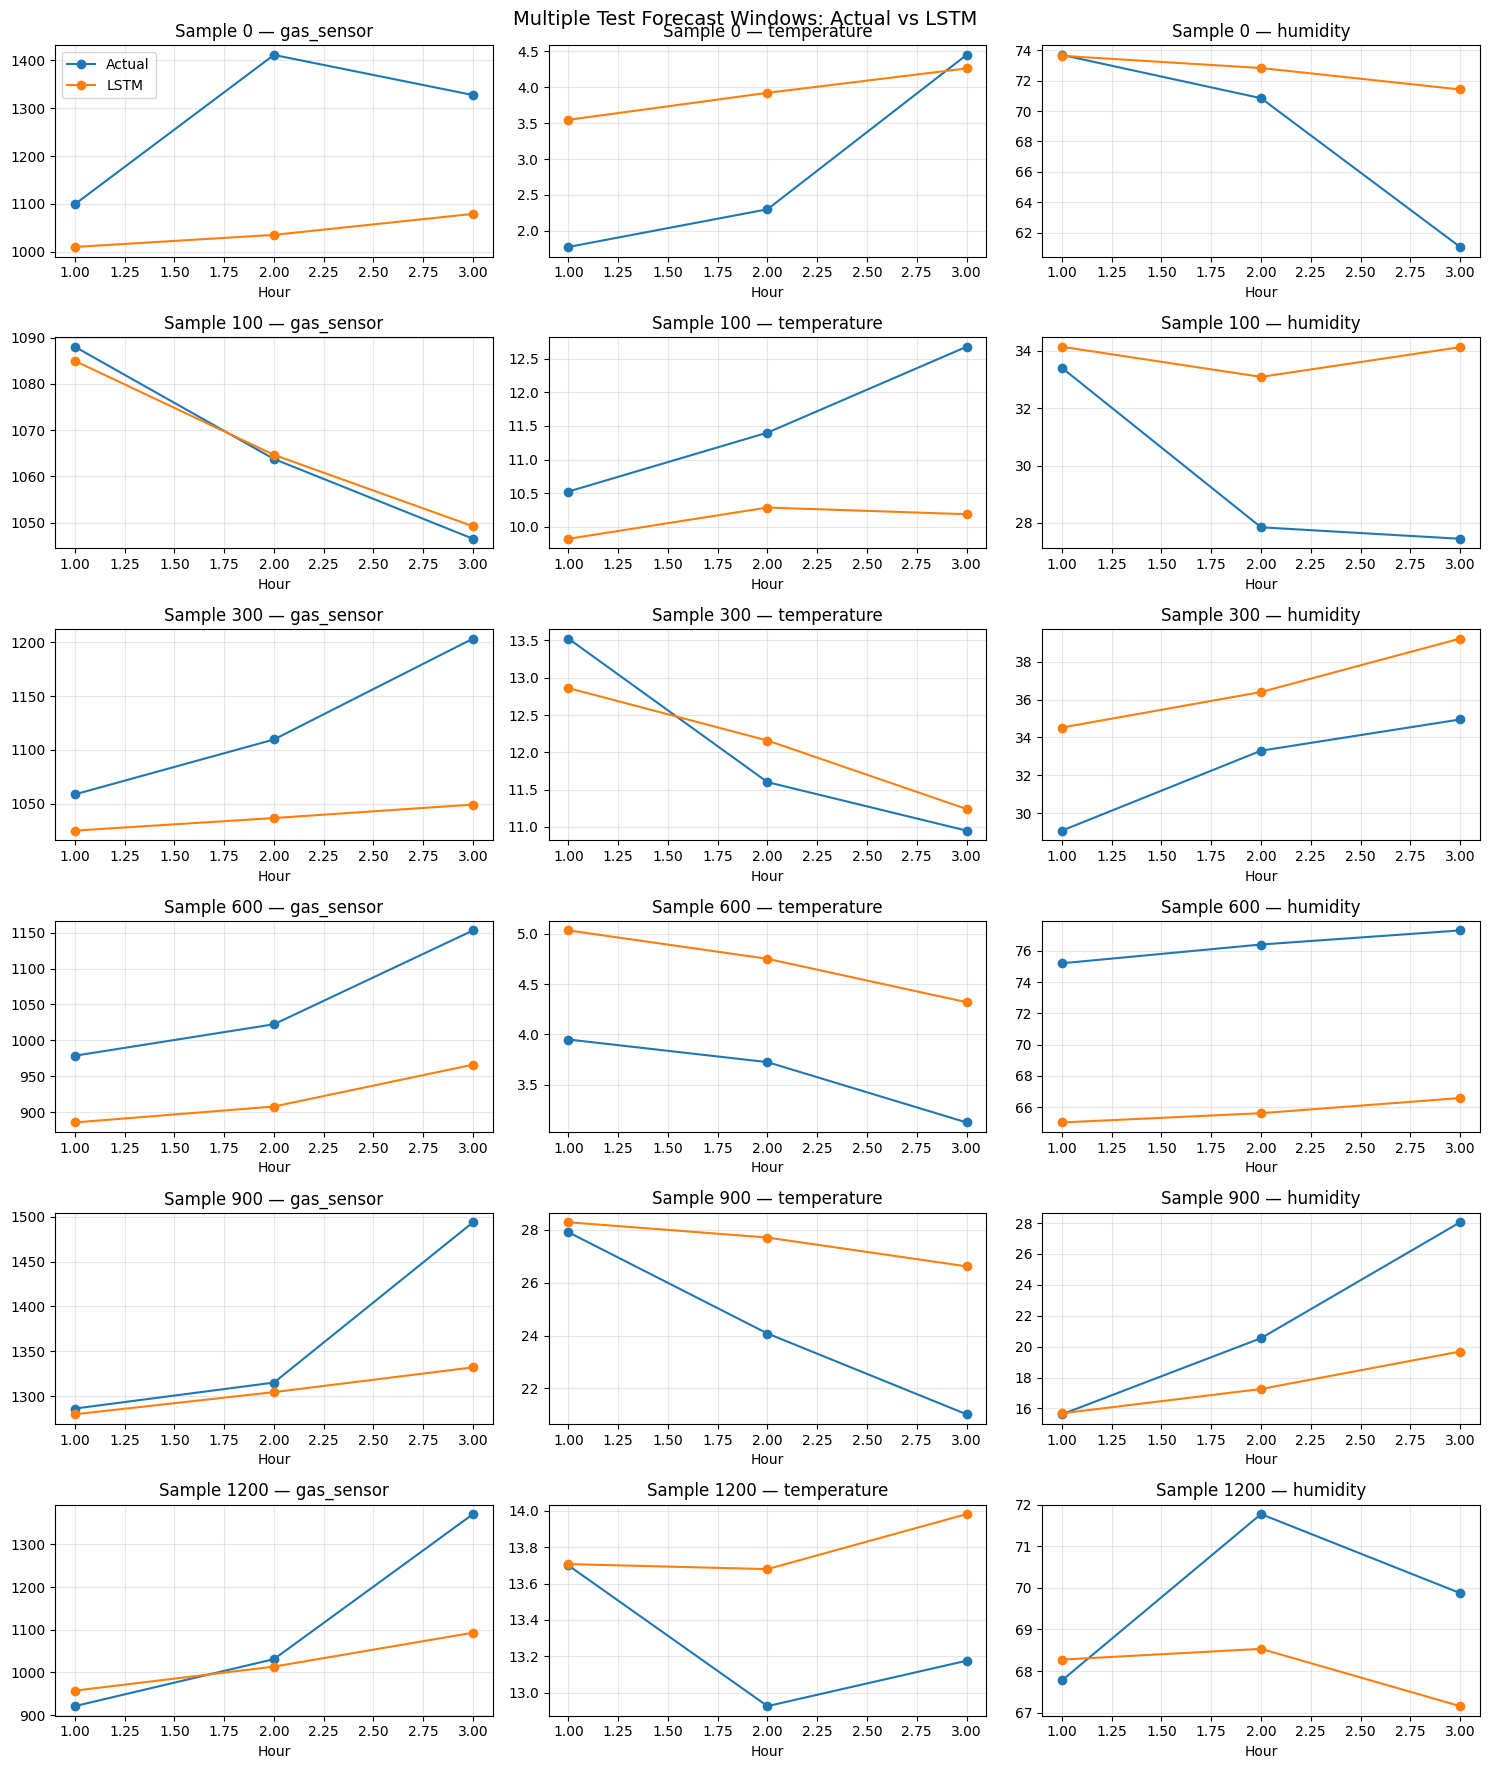

In [ ]:
sample_indices = [0, 100, 300, 600, 900, 1200]

fig, axes = plt.subplots(
    len(sample_indices),
    3,
    figsize=(15, 3 * len(sample_indices))
)

for row, sample_idx in enumerate(sample_indices):

    for col, name in enumerate(target_names):

        axes[row, col].plot(
            range(1, HORIZON + 1),
            y_test_real[sample_idx, :, col],
            marker="o",
            label="Actual"
        )

        axes[row, col].plot(
            range(1, HORIZON + 1),
            y_pred_real[sample_idx, :, col],
            marker="o",
            label="LSTM"
        )

        axes[row, col].set_title(
            f"Sample {sample_idx} — {name}"
        )

        axes[row, col].set_xlabel("Hour")
        axes[row, col].grid(True, alpha=0.3)

        if row == 0 and col == 0:
            axes[row, col].legend()

plt.suptitle(
    "Multiple Test Forecast Windows: Actual vs LSTM",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
def check_sequence_continuity(timestamps, lookback, horizon):
    timestamps = pd.to_datetime(timestamps).reset_index(drop=True)

    bad_input = 0
    bad_target = 0
    bad_boundary = 0

    for i in range(len(timestamps) - lookback - horizon + 1):

        input_times = timestamps.iloc[i:i + lookback]
        target_times = timestamps.iloc[
            i + lookback:i + lookback + horizon
        ]

      
        input_diff = input_times.diff().dropna()

       
        target_diff = target_times.diff().dropna()

       
        boundary_diff = (
            target_times.iloc[0] - input_times.iloc[-1]
        )

        if not (input_diff == pd.Timedelta(hours=1)).all():
            bad_input += 1

        if not (target_diff == pd.Timedelta(hours=1)).all():
            bad_target += 1

        if boundary_diff != pd.Timedelta(hours=1):
            bad_boundary += 1

    total_sequences = (
        len(timestamps) - lookback - horizon + 1
    )

    print("Total sequences checked:", total_sequences)
    print("Sequences with input gaps:", bad_input)
    print("Sequences with target gaps:", bad_target)
    print("Sequences with input-target boundary gaps:", bad_boundary)

    if bad_input == 0 and bad_target == 0 and bad_boundary == 0:
        print("\n✓ All sequences are temporally continuous.")
    else:
        print("\n⚠ Some sequences contain timestamp gaps.")

In [17]:
print("TRAIN")
check_sequence_continuity(
    train_df["timestamp"],
    LOOKBACK,
    HORIZON
)

print("\nVALIDATION")
check_sequence_continuity(
    val_df["timestamp"],
    LOOKBACK,
    HORIZON
)

print("\nTEST")
check_sequence_continuity(
    test_df["timestamp"],
    LOOKBACK,
    HORIZON
)

TRAIN
Total sequences checked: 6338
Sequences with input gaps: 30
Sequences with target gaps: 12
Sequences with input-target boundary gaps: 6

⚠ Some sequences contain timestamp gaps.

VALIDATION
Total sequences checked: 1352
Sequences with input gaps: 15
Sequences with target gaps: 6
Sequences with input-target boundary gaps: 3

⚠ Some sequences contain timestamp gaps.

TEST
Total sequences checked: 1352
Sequences with input gaps: 5
Sequences with target gaps: 2
Sequences with input-target boundary gaps: 1

⚠ Some sequences contain timestamp gaps.


In [ ]:
def create_continuous_sequences(
    df,
    feature_columns,
    target_columns,
    lookback,
    horizon,
    expected_interval="1h"
):
    timestamps = pd.to_datetime(
        df["timestamp"]
    ).reset_index(drop=True)

    X_values = df[feature_columns].to_numpy(
        dtype=np.float32
    )

    y_values = df[target_columns].to_numpy(
        dtype=np.float32
    )

    expected_delta = pd.Timedelta(expected_interval)

    X_seq = []
    y_seq = []

    rejected = 0

    for i in range(
        len(df) - lookback - horizon + 1
    ):

        window_times = timestamps.iloc[
            i:i + lookback + horizon
        ]

        time_diffs = window_times.diff().dropna()

        # Entire input + forecast window must be continuous
        if (time_diffs == expected_delta).all():

            X_seq.append(
                X_values[i:i + lookback]
            )

            y_seq.append(
                y_values[
                    i + lookback:
                    i + lookback + horizon
                ]
            )

        else:
            rejected += 1

    X_seq = np.asarray(
        X_seq,
        dtype=np.float32
    )

    y_seq = np.asarray(
        y_seq,
        dtype=np.float32
    )

    return X_seq, y_seq, rejected

In [ ]:
model_features = ["gas_sensor", "temperature", "humidity"]
target_features = ["gas_sensor", "temperature", "humidity"]

X_train_clean, y_train_clean, rejected_train = (
    create_continuous_sequences(
        train_df,
        model_features,
        target_features,
        LOOKBACK,
        HORIZON
    )
)

X_val_clean, y_val_clean, rejected_val = (
    create_continuous_sequences(
        val_df,
        model_features,
        target_features,
        LOOKBACK,
        HORIZON
    )
)

X_test_clean, y_test_clean, rejected_test = (
    create_continuous_sequences(
        test_df,
        model_features,
        target_features,
        LOOKBACK,
        HORIZON
    )
)

print("Corrected sequence shapes")
print("=" * 60)

print("X_train:", X_train_clean.shape)
print("y_train:", y_train_clean.shape)

print("X_val:  ", X_val_clean.shape)
print("y_val:  ", y_val_clean.shape)

print("X_test: ", X_test_clean.shape)
print("y_test: ", y_test_clean.shape)

print("\nRejected sequences")
print("=" * 60)

print("Train:", rejected_train)
print("Validation:", rejected_val)
print("Test:", rejected_test)

Corrected sequence shapes
X_train: (6291, 6, 3)
y_train: (6291, 3, 3)
X_val:   (1328, 6, 3)
y_val:   (1328, 3, 3)
X_test:  (1344, 6, 3)
y_test:  (1344, 3, 3)

Rejected sequences
Train: 47
Validation: 24
Test: 8


In [ ]:
n_features = 3
n_targets = 3

model_clean = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),
    layers.LSTM(
        32,
        activation="tanh",
        return_sequences=False
    ),
    layers.Dropout(0.2),
    layers.Dense(
        HORIZON * n_targets
    ),
    layers.Reshape(
        (HORIZON, n_targets)
    )
])

model_clean.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mae",
    metrics=["mae"]
)

model_clean.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           297 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 3, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,905 (19.16 KB)

 Trainable params: 4,905 (19.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_clean = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_clean = model_clean.fit(
    X_train_clean,
    y_train_clean,
    validation_data=(
        X_val_clean,
        y_val_clean
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_clean],
    verbose=1
)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 388.8160 - mae: 388.8160 - val_loss: 386.1606 - val_mae: 386.1606
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 387.0323 - mae: 387.0323 - val_loss: 384.4402 - val_mae: 384.4402
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 385.3076 - mae: 385.3076 - val_loss: 382.8563 - val_mae: 382.8563
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 383.5813 - mae: 383.5813 - val_loss: 381.4265 - val_mae: 381.4265
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 381.8544 - mae: 381.8544 - val_loss: 380.1390 - val_mae: 380.1390
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 380.2337 - mae: 380.2337 - val_loss: 378.9970 - val_mae: 378.9970
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 378.5966 - mae: 378.5966 - val_loss: 377.9597 - val_mae: 377.9596
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 377.0424 - mae: 377.0424 - val_loss: 377.0359 - v

In [ ]:
print("X_train_clean range:")
print("min:", X_train_clean.min())
print("max:", X_train_clean.max())
print("mean:", X_train_clean.mean())
print("std:", X_train_clean.std())

print("\ny_train_clean range:")
print("min:", y_train_clean.min())
print("max:", y_train_clean.max())
print("mean:", y_train_clean.mean())
print("std:", y_train_clean.std())

print("\nNaN / Inf check:")
print("X_train NaN:", np.isnan(X_train_clean).sum())
print("y_train NaN:", np.isnan(y_train_clean).sum())
print("X_train Inf:", np.isinf(X_train_clean).sum())
print("y_train Inf:", np.isinf(y_train_clean).sum())

X_train_clean range:
min: 1.3
max: 2039.75
mean: 389.6376
std: 518.09973

y_train_clean range:
min: 1.3
max: 2039.75
mean: 389.61853
std: 518.05774

NaN / Inf check:
X_train NaN: 0
y_train NaN: 0
X_train Inf: 0
y_train Inf: 0


In [ ]:
scaled_columns = [
    "gas_sensor",
    "temperature",
    "humidity"
]

train_scaled_df = train_df[
    ["timestamp"] + scaled_columns
].copy()

val_scaled_df = val_df[
    ["timestamp"] + scaled_columns
].copy()

test_scaled_df = test_df[
    ["timestamp"] + scaled_columns
].copy()

train_scaled_df[scaled_columns] = scaler.transform(
    train_scaled_df[scaled_columns]
)

val_scaled_df[scaled_columns] = scaler.transform(
    val_scaled_df[scaled_columns]
)

test_scaled_df[scaled_columns] = scaler.transform(
    test_scaled_df[scaled_columns]
)

print("Scaled train:")
print(train_scaled_df[scaled_columns].describe())

print("\nScaled validation:")
print(val_scaled_df[scaled_columns].describe())

print("\nScaled test:")
print(test_scaled_df[scaled_columns].describe())

Scaled train:
         gas_sensor   temperature      humidity
count  6.346000e+03  6.346000e+03  6.346000e+03
mean  -3.672518e-16 -2.508061e-16 -3.582945e-17
std    1.000079e+00  1.000079e+00  1.000079e+00
min   -2.053061e+00 -2.674481e+00 -2.212073e+00
25%   -7.461617e-01 -7.437811e-01 -7.933280e-01
50%   -1.676544e-01 -6.542710e-02  1.352250e-02
75%    6.106543e-01  6.324948e-01  7.573096e-01
max    4.265889e+00  2.974121e+00  2.285244e+00

Scaled validation:
        gas_sensor  temperature     humidity
count  1360.000000  1360.000000  1360.000000
mean     -0.002066    -1.632360     0.466770
std       1.006711     0.525588     0.889141
min      -1.855665    -2.713617    -1.802702
25%      -0.819334    -2.084183    -0.151523
50%      -0.178364    -1.634121     0.505056
75%       0.693470    -1.203627     1.142537
max       3.545506    -0.195880     2.374614

Scaled test:
        gas_sensor  temperature     humidity
count  1360.000000  1360.000000  1360.000000
mean      0.019934    -1.

In [ ]:
X_train_clean, y_train_clean, rejected_train = (
    create_continuous_sequences(
        train_scaled_df,
        model_features,
        target_features,
        LOOKBACK,
        HORIZON
    )
)

X_val_clean, y_val_clean, rejected_val = (
    create_continuous_sequences(
        val_scaled_df,
        model_features,
        target_features,
        LOOKBACK,
        HORIZON
    )
)

X_test_clean, y_test_clean, rejected_test = (
    create_continuous_sequences(
        test_scaled_df,
        model_features,
        target_features,
        LOOKBACK,
        HORIZON
    )
)

print("Corrected scaled sequence shapes")
print("=" * 60)

print("X_train:", X_train_clean.shape)
print("y_train:", y_train_clean.shape)

print("X_val:  ", X_val_clean.shape)
print("y_val:  ", y_val_clean.shape)

print("X_test: ", X_test_clean.shape)
print("y_test: ", y_test_clean.shape)

print("\nRejected sequences")
print("=" * 60)

print("Train:", rejected_train)
print("Validation:", rejected_val)
print("Test:", rejected_test)

print("\nSequence data statistics")
print("=" * 60)

print("X_train mean:", X_train_clean.mean())
print("X_train std :", X_train_clean.std())
print("y_train mean:", y_train_clean.mean())
print("y_train std :", y_train_clean.std())

Corrected scaled sequence shapes
X_train: (6291, 6, 3)
y_train: (6291, 3, 3)
X_val:   (1328, 6, 3)
y_val:   (1328, 3, 3)
X_test:  (1344, 6, 3)
y_test:  (1344, 3, 3)

Rejected sequences
Train: 47
Validation: 24
Test: 8

Sequence data statistics
X_train mean: 0.0005573216
X_train std : 1.0000807
y_train mean: 0.00062250975
y_train std : 1.0005151


In [ ]:
n_features = 3
n_targets = 3

model_clean = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),
    layers.LSTM(
        32,
        activation="tanh",
        return_sequences=False
    ),
    layers.Dropout(0.2),
    layers.Dense(HORIZON * n_targets),
    layers.Reshape((HORIZON, n_targets))
])

model_clean.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae",
    metrics=["mae"]
)

model_clean.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 3, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,905 (19.16 KB)

 Trainable params: 4,905 (19.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping_clean = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_clean = model_clean.fit(
    X_train_clean,
    y_train_clean,
    validation_data=(X_val_clean, y_val_clean),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_clean],
    verbose=1
)

Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.5774 - mae: 0.5774 - val_loss: 0.4168 - val_mae: 0.4168
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4152 - mae: 0.4152 - val_loss: 0.3568 - val_mae: 0.3568
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3633 - mae: 0.3633 - val_loss: 0.3295 - val_mae: 0.3295
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3461 - mae: 0.3461 - val_loss: 0.3105 - val_mae: 0.3105
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3351 - mae: 0.3351 - val_loss: 0.3069 - val_mae: 0.3069
Epoch 6/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3307 - mae: 0.3307 - val_loss: 0.2985 - val_mae: 0.2985
Epoch 7/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3255 - mae: 0.3255 - val_loss: 0.2902 - val_mae: 0.2902
Epoch 8/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3190 - mae: 0.3190 - val_loss: 0.2895 - val_mae: 0.2895
Epoch 9/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

In [ ]:
y_pred_clean = model_clean.predict(
    X_test_clean,
    verbose=0
)


y_persistence_clean = np.repeat(
    X_test_clean[:, -1:, :],
    HORIZON,
    axis=1
)

print("Prediction shapes")
print("=" * 60)
print("Actual:       ", y_test_clean.shape)
print("LSTM:         ", y_pred_clean.shape)
print("Persistence:  ", y_persistence_clean.shape)

print("\nNaN / Inf check")
print("LSTM NaN:", np.isnan(y_pred_clean).sum())
print("LSTM Inf:", np.isinf(y_pred_clean).sum())

Prediction shapes
Actual:        (1344, 3, 3)
LSTM:          (1344, 3, 3)
Persistence:   (1344, 3, 3)

NaN / Inf check
LSTM NaN: 0
LSTM Inf: 0


In [ ]:
lstm_mae = mean_absolute_error(
    y_test_clean.reshape(-1),
    y_pred_clean.reshape(-1)
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_clean.reshape(-1),
        y_pred_clean.reshape(-1)
    )
)

baseline_mae = mean_absolute_error(
    y_test_clean.reshape(-1),
    y_persistence_clean.reshape(-1)
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_clean.reshape(-1),
        y_persistence_clean.reshape(-1)
    )
)

mae_improvement = (
    (baseline_mae - lstm_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - lstm_rmse) / baseline_rmse
) * 100

print("OVERALL TEST PERFORMANCE")
print("=" * 60)

print(f"LSTM MAE:          {lstm_mae:.4f}")
print(f"Persistence MAE:   {baseline_mae:.4f}")
print(f"MAE improvement:   {mae_improvement:.2f}%")

print()

print(f"LSTM RMSE:         {lstm_rmse:.4f}")
print(f"Persistence RMSE:  {baseline_rmse:.4f}")
print(f"RMSE improvement:  {rmse_improvement:.2f}%")

OVERALL TEST PERFORMANCE
LSTM MAE:          0.2743
Persistence MAE:   0.3454
MAE improvement:   20.59%

LSTM RMSE:         0.4096
Persistence RMSE:  0.5128
RMSE improvement:  20.13%


In [ ]:
variable_names = [
    "gas_sensor",
    "temperature",
    "humidity"
]

print("PER-VARIABLE TEST PERFORMANCE")
print("=" * 75)

for i, name in enumerate(variable_names):

    actual = y_test_clean[:, :, i].reshape(-1)
    pred = y_pred_clean[:, :, i].reshape(-1)
    persistence = y_persistence_clean[:, :, i].reshape(-1)

    mae_lstm = mean_absolute_error(actual, pred)
    mae_base = mean_absolute_error(actual, persistence)

    rmse_lstm = np.sqrt(
        mean_squared_error(actual, pred)
    )
    rmse_base = np.sqrt(
        mean_squared_error(actual, persistence)
    )

    mae_imp = ((mae_base - mae_lstm) / mae_base) * 100
    rmse_imp = ((rmse_base - rmse_lstm) / rmse_base) * 100

    print(f"\n{name.upper()}")
    print("-" * 75)

    print(f"LSTM MAE:          {mae_lstm:.4f}")
    print(f"Persistence MAE:   {mae_base:.4f}")
    print(f"MAE improvement:   {mae_imp:.2f}%")

    print(f"LSTM RMSE:         {rmse_lstm:.4f}")
    print(f"Persistence RMSE:  {rmse_base:.4f}")
    print(f"RMSE improvement:  {rmse_imp:.2f}%")

PER-VARIABLE TEST PERFORMANCE

GAS_SENSOR
---------------------------------------------------------------------------
LSTM MAE:          0.3921
Persistence MAE:   0.4701
MAE improvement:   16.59%
LSTM RMSE:         0.5564
Persistence RMSE:  0.6702
RMSE improvement:  16.98%

TEMPERATURE
---------------------------------------------------------------------------
LSTM MAE:          0.1630
Persistence MAE:   0.2177
MAE improvement:   25.13%
LSTM RMSE:         0.2258
Persistence RMSE:  0.3181
RMSE improvement:  29.01%

HUMIDITY
---------------------------------------------------------------------------
LSTM MAE:          0.2678
Persistence MAE:   0.3485
MAE improvement:   23.16%
LSTM RMSE:         0.3779
Persistence RMSE:  0.4886
RMSE improvement:  22.66%


In [ ]:
print("HORIZON-WISE TEST PERFORMANCE")
print("=" * 80)

for h in range(HORIZON):

    actual = y_test_clean[:, h, :].reshape(-1)
    pred = y_pred_clean[:, h, :].reshape(-1)
    persistence = y_persistence_clean[:, h, :].reshape(-1)

    mae_lstm = mean_absolute_error(actual, pred)
    mae_base = mean_absolute_error(actual, persistence)

    rmse_lstm = np.sqrt(
        mean_squared_error(actual, pred)
    )
    rmse_base = np.sqrt(
        mean_squared_error(actual, persistence)
    )

    mae_imp = ((mae_base - mae_lstm) / mae_base) * 100
    rmse_imp = ((rmse_base - rmse_lstm) / rmse_base) * 100

    print(f"\n+{h+1} HOUR")
    print("-" * 80)

    print(f"LSTM MAE:          {mae_lstm:.4f}")
    print(f"Persistence MAE:   {mae_base:.4f}")
    print(f"MAE improvement:   {mae_imp:.2f}%")

    print(f"LSTM RMSE:         {rmse_lstm:.4f}")
    print(f"Persistence RMSE:  {rmse_base:.4f}")
    print(f"RMSE improvement:  {rmse_imp:.2f}%")

HORIZON-WISE TEST PERFORMANCE

+1 HOUR
--------------------------------------------------------------------------------
LSTM MAE:          0.1788
Persistence MAE:   0.2072
MAE improvement:   13.72%
LSTM RMSE:         0.2680
Persistence RMSE:  0.3124
RMSE improvement:  14.22%

+2 HOUR
--------------------------------------------------------------------------------
LSTM MAE:          0.2866
Persistence MAE:   0.3548
MAE improvement:   19.24%
LSTM RMSE:         0.4172
Persistence RMSE:  0.5110
RMSE improvement:  18.35%

+3 HOUR
--------------------------------------------------------------------------------
LSTM MAE:          0.3576
Persistence MAE:   0.4743
MAE improvement:   24.60%
LSTM RMSE:         0.5074
Persistence RMSE:  0.6560
RMSE improvement:  22.65%


In [ ]:
y_test_real = scaler.inverse_transform(
    y_test_clean.reshape(-1, n_features)
).reshape(y_test_clean.shape)

y_pred_real = scaler.inverse_transform(
    y_pred_clean.reshape(-1, n_features)
).reshape(y_pred_clean.shape)

y_persistence_real = scaler.inverse_transform(
    y_persistence_clean.reshape(-1, n_features)
).reshape(y_persistence_clean.shape)

print("Real-unit shapes")
print("=" * 60)

print("Actual:       ", y_test_real.shape)
print("LSTM:         ", y_pred_real.shape)
print("Persistence:  ", y_persistence_real.shape)

Real-unit shapes
Actual:        (1344, 3, 3)
LSTM:          (1344, 3, 3)
Persistence:   (1344, 3, 3)


In [ ]:
print("REAL-UNIT TEST PERFORMANCE")
print("=" * 80)

for i, name in enumerate(variable_names):

    actual = y_test_real[:, :, i].reshape(-1)
    pred = y_pred_real[:, :, i].reshape(-1)
    persistence = y_persistence_real[:, :, i].reshape(-1)

    mae_lstm = mean_absolute_error(actual, pred)
    mae_base = mean_absolute_error(actual, persistence)

    rmse_lstm = np.sqrt(
        mean_squared_error(actual, pred)
    )
    rmse_base = np.sqrt(
        mean_squared_error(actual, persistence)
    )

    mae_imp = ((mae_base - mae_lstm) / mae_base) * 100
    rmse_imp = ((rmse_base - rmse_lstm) / rmse_base) * 100

    print(f"\n{name.upper()}")
    print("-" * 80)

    print(f"LSTM MAE:          {mae_lstm:.3f}")
    print(f"Persistence MAE:   {mae_base:.3f}")
    print(f"MAE improvement:   {mae_imp:.2f}%")

    print(f"LSTM RMSE:         {rmse_lstm:.3f}")
    print(f"Persistence RMSE:  {rmse_base:.3f}")
    print(f"RMSE improvement:  {rmse_imp:.2f}%")

REAL-UNIT TEST PERFORMANCE

GAS_SENSOR
--------------------------------------------------------------------------------
LSTM MAE:          86.404
Persistence MAE:   103.586
MAE improvement:   16.59%
LSTM RMSE:         122.611
Persistence RMSE:  147.690
RMSE improvement:  16.98%

TEMPERATURE
--------------------------------------------------------------------------------
LSTM MAE:          1.250
Persistence MAE:   1.669
MAE improvement:   25.13%
LSTM RMSE:         1.731
Persistence RMSE:  2.438
RMSE improvement:  29.01%

HUMIDITY
--------------------------------------------------------------------------------
LSTM MAE:          4.645
Persistence MAE:   6.045
MAE improvement:   23.16%
LSTM RMSE:         6.553
Persistence RMSE:  8.473
RMSE improvement:  22.66%


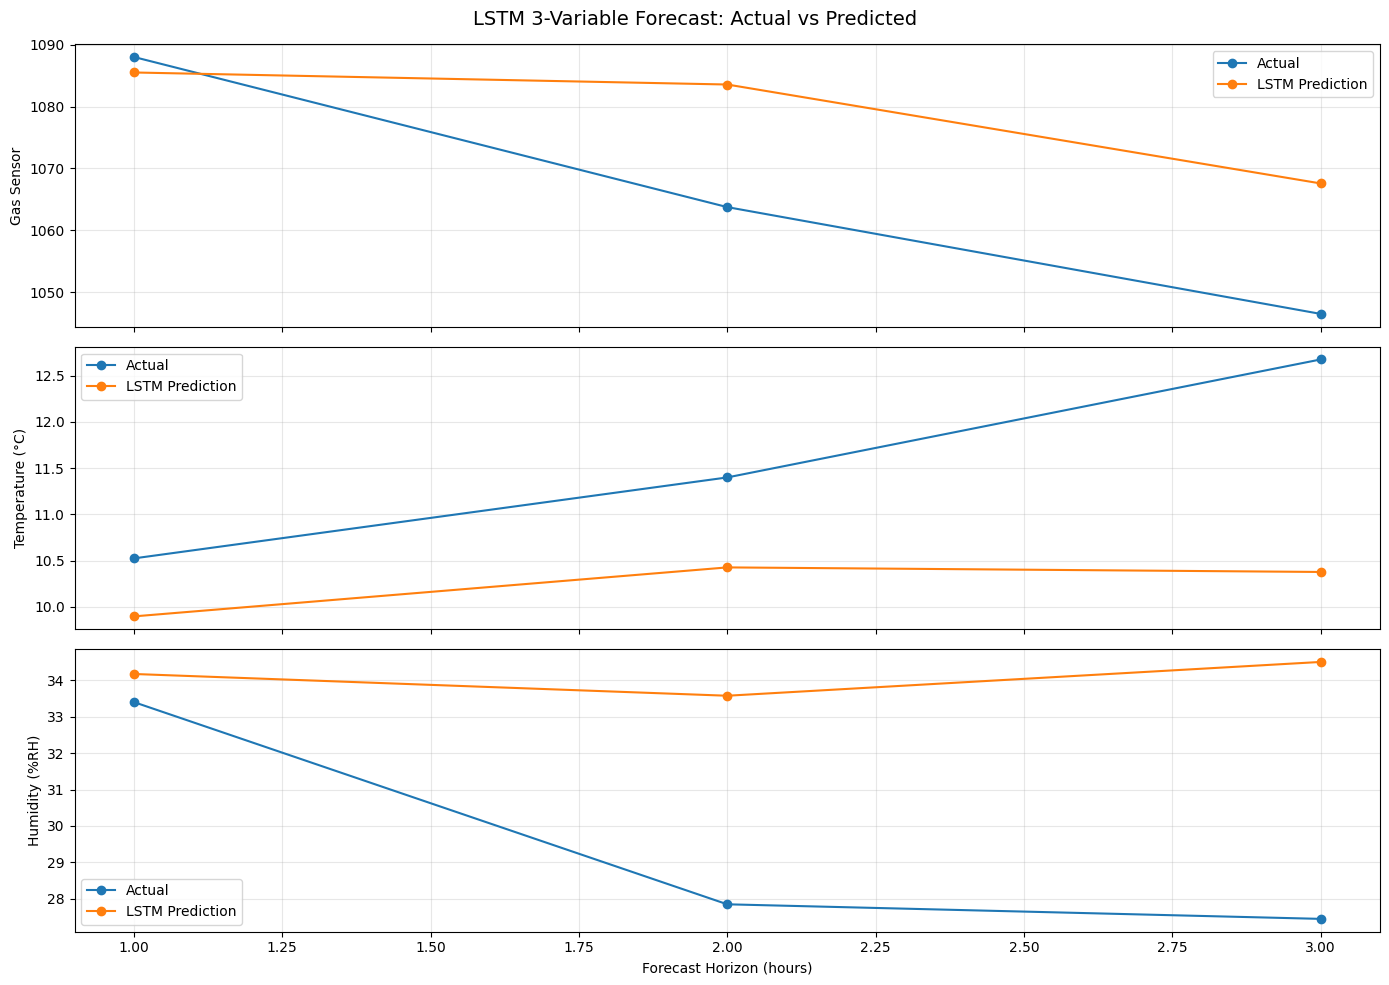

In [ ]:
sample_idx = 100

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 10),
    sharex=True
)

variable_labels = [
    "Gas Sensor",
    "Temperature (°C)",
    "Humidity (%RH)"
]

for i in range(3):

    axes[i].plot(
        range(1, HORIZON + 1),
        y_test_real[sample_idx, :, i],
        marker="o",
        label="Actual"
    )

    axes[i].plot(
        range(1, HORIZON + 1),
        y_pred_real[sample_idx, :, i],
        marker="o",
        label="LSTM Prediction"
    )

    axes[i].set_ylabel(variable_labels[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

axes[-1].set_xlabel("Forecast Horizon (hours)")

fig.suptitle(
    "LSTM 3-Variable Forecast: Actual vs Predicted",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
MQ_CLEAN = 1000.0
MQ_POLLUTED = 3000.0
SAQI_MAX = 500.0

def calculate_saqi(raw_mq):
    saqi = (
        (raw_mq - MQ_CLEAN)
        / (MQ_POLLUTED - MQ_CLEAN)
    ) * SAQI_MAX

    return float(np.clip(saqi, 0, SAQI_MAX))

In [ ]:
last_timestamp = pd.Timestamp("2026-10-01 13:00:00")


forecast = y_pred_real[0]   

forecast_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=3,
    freq="1h"
)

forecast_table = pd.DataFrame({
    "timestamp": forecast_timestamps,
    "temperature": forecast[:, 1],
    "humidity": forecast[:, 2],
    "mq135_adc": forecast[:, 0],
})

forecast_table["saqi"] = forecast_table["mq135_adc"].apply(calculate_saqi)

forecast_table["temperature"] = forecast_table["temperature"].round(2)
forecast_table["humidity"] = forecast_table["humidity"].round(2)
forecast_table["mq135_adc"] = forecast_table["mq135_adc"].round(2)
forecast_table["saqi"] = forecast_table["saqi"].round(2)

display(forecast_table)

,timestamp,temperature,humidity,mq135_adc,saqi
0,2026-10-01 14:00:00,3.03,74.029999,1002.859985,0.72
1,2026-10-01 15:00:00,3.67,72.419998,1010.309998,2.58
2,2026-10-01 16:00:00,4.36,70.449997,1037.660034,9.42


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_clean)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("air_quality_lstm.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully.")
print("Size:", len(tflite_model) / 1024, "KB")

Saved artifact at '/tmp/tmpnh2s_lm8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6, 3), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 3, 3), dtype=tf.float32, name=None)
Captures:
  136360614395984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136360614398864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136360865600848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136360614398672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136360865600656: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved successfully.
Size: 30.91015625 KB


In [40]:
import joblib

joblib.dump(scaler, "air_quality_scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.
